# Benchmark Analysis: Aggregate Results

This notebook analyzes the benchmark output in `results/all_benchmarks_aggregate.json`.

It focuses on:
- Overall benchmark health (success rate, runtime)
- Per-agent and per-benchmark performance
- Error diagnostics for failed runs
- Detection quality (false positives and missed anomalies)

In [10]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [11]:
candidate_paths = [
    Path("results/all_benchmarks_aggregate.json"),
    Path("../../../../results/all_benchmarks_aggregate.json"),
    Path("/home/isaacp/repos/directlabs/JFN-Groundtruth-Simulator/results/all_benchmarks_aggregate.json"),
]

json_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError("Could not locate results/all_benchmarks_aggregate.json")

with json_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Loaded: {json_path}")
print(f"Started at:  {data.get('started_at')}")
print(f"Finished at: {data.get('finished_at')}")
print(f"Total runs:  {data.get('summary', {}).get('total_runs')}")

Loaded: /home/isaacp/repos/direct/JFN-Groundtruth-Tools/actint/src/actint/benchmarking/results/all_benchmarks_aggregate.json
Started at:  2026-04-07T03:08:40.452391+00:00
Finished at: 2026-04-07T05:48:47.426161+00:00
Total runs:  12


## Normalize Run-Level Data

Convert nested result objects into a flat DataFrame and derive quality metrics per run:
- success/failure
- detected expected anomalies
- false positives
- misses
- precision, recall, and F1

In [12]:
runs = pd.json_normalize(data.get("results", []), sep=".")
runs.keys()


Index(['agent', 'model_id', 'benchmark_id', 'run_index', 'prompt', 'duration_sec', 'agent_output', 'runtime_inputs.expected_loitering_mmsis',
       'validation.success', 'validation.expected.expected_loitering_mmsis', 'validation.expected.expected_count', 'validation.predicted.reported_mmsis',
       'validation.predicted.reported_count', 'validation.metrics.minimum_detected', 'validation.metrics.detected_expected_count',
       'validation.metrics.detected_expected_percent', 'validation.metrics.detected_expected_mmsis', 'validation.metrics.missed_expected_mmsis',
       'validation.metrics.false_positive_mmsis', 'runtime_inputs.expected_speeding_mmsis', 'validation.expected.expected_speeding_mmsis',
       'runtime_inputs.expected_disappearance_mmsis', 'validation.expected.expected_disappearance_mmsis'],
      dtype='str')

In [13]:
runs = pd.json_normalize(data.get("results", []), sep=".")

if runs.empty:
    raise ValueError("No runs found in the aggregate JSON")

runs["success"] = runs["validation.success"].fillna(False).astype(bool)
runs["duration_sec"] = pd.to_numeric(runs["duration_sec"], errors="coerce")
runs["expected_count"] = pd.to_numeric(runs["validation.expected.expected_count"], errors="coerce").fillna(0).astype(int)
runs["detected_expected_count"] = pd.to_numeric(runs["validation.metrics.detected_expected_count"], errors="coerce").fillna(0).astype(int)

runs["false_positive_mmsis"] = runs["validation.metrics.false_positive_mmsis"].apply(lambda x: x if isinstance(x, list) else [])
runs["missed_expected_mmsis"] = runs["validation.metrics.missed_expected_mmsis"].apply(lambda x: x if isinstance(x, list) else [])

runs["false_positive_count"] = runs["false_positive_mmsis"].apply(len)
runs["missed_count"] = runs["missed_expected_mmsis"].apply(len)

predicted_total = runs["detected_expected_count"] + runs["false_positive_count"]
runs["precision"] = np.where(predicted_total > 0, runs["detected_expected_count"] / predicted_total, np.nan)
runs["recall"] = np.where(runs["expected_count"] > 0, runs["detected_expected_count"] / runs["expected_count"], np.nan)
runs["f1"] = np.where(
    (runs["precision"] + runs["recall"]) > 0,
    2 * runs["precision"] * runs["recall"] / (runs["precision"] + runs["recall"]),
    np.nan,
)

cols = [
    "agent",
    "model_id",
    "benchmark_id",
    "run_index",
    "success",
    "duration_sec",
    "expected_count",
    "detected_expected_count",
    "false_positive_count",
    "missed_count",
    "precision",
    "recall",
    "f1",
]

runs[cols].sort_values(["benchmark_id", "agent", "run_index"]).reset_index(drop=True)

,agent,model_id,benchmark_id,run_index,success,duration_sec,expected_count,detected_expected_count,false_positive_count,missed_count,precision,recall,f1
0,Qwen/Qwen3.5-27B,Qwen/Qwen3.5-27B,disappearance_detection_injected,0,True,483.392771,10,10,0,0,1.000000,1.0,1.000000
1,Qwen/Qwen3.5-35B-A3B,Qwen/Qwen3.5-35B-A3B,disappearance_detection_injected,0,True,951.436507,10,10,0,0,1.000000,1.0,1.000000
2,qwen2_7b_instruct,Qwen/Qwen2-7B-Instruct,disappearance_detection_injected,0,False,400.127464,10,0,0,10,NaN,0.0,NaN
3,qwen35_9b,Qwen/Qwen3.5-9B,disappearance_detection_injected,0,False,1734.000624,10,0,0,10,NaN,0.0,NaN
4,Qwen/Qwen3.5-27B,Qwen/Qwen3.5-27B,loitering_detection_injected,0,True,291.774708,10,10,0,0,1.000000,1.0,1.000000
5,Qwen/Qwen3.5-35B-A3B,Qwen/Qwen3.5-35B-A3B,loitering_detection_injected,0,True,666.826064,10,10,0,0,1.000000,1.0,1.000000
6,qwen2_7b_instruct,Qwen/Qwen2-7B-Instruct,loitering_detection_injected,0,False,328.804113,10,0,0,10,NaN,0.0,NaN
7,qwen35_9b,Qwen/Qwen3.5-9B,loitering_detection_injected,0,True,203.833214,10,10,0,0,1.000000,1.0,1.000000
8,Qwen/Qwen3.5-27B,Qwen/Qwen3.5-27B,speeding_detection_injected,0,True,172.607388,10,10,0,0,1.000000,1.0,1.000000
9,Qwen/Qwen3.5-35B-A3B,Qwen/Qwen3.5-35B-A3B,speeding_detection_injected,0,True,185.996514,10,10,2,0,0.833333,1.0,0.909091


## Top-Level Summary

Compare values from the JSON summary block with metrics recomputed from run-level data.

In [14]:
json_summary = data.get("summary", {})

recomputed = {
    "total_runs": int(len(runs)),
    "successful_runs": int(runs["success"].sum()),
    "success_rate": float(runs["success"].mean()),
    "average_duration_sec": float(runs["duration_sec"].mean()),
}

comparison = pd.DataFrame(
    {
        "from_json": {
            "total_runs": json_summary.get("total_runs"),
            "successful_runs": json_summary.get("successful_runs"),
            "success_rate": json_summary.get("success_rate"),
            "average_duration_sec": json_summary.get("average_duration_sec"),
        },
        "recomputed": recomputed,
    }
)
comparison

,from_json,recomputed
total_runs,12.000000,12.000000
successful_runs,8.000000,8.000000
success_rate,NaN,0.666667
average_duration_sec,468.851055,468.851055


## Agent Performance

Aggregate by agent/model to inspect speed and detection quality.

In [15]:
agent_perf = (
    runs.groupby(["agent", "model_id"], dropna=False)
    .agg(
        runs=("agent", "size"),
        success_rate=("success", "mean"),
        avg_duration_sec=("duration_sec", "mean"),
        avg_precision=("precision", "mean"),
        avg_recall=("recall", "mean"),
        avg_f1=("f1", "mean"),
        avg_false_positives=("false_positive_count", "mean"),
        avg_missed=("missed_count", "mean"),
    )
    .sort_values(["success_rate", "avg_f1", "avg_duration_sec"], ascending=[False, False, True])
)

agent_perf

,,runs,success_rate,avg_duration_sec,avg_precision,avg_recall,avg_f1,avg_false_positives,avg_missed
agent,model_id,,,,,,,,
Qwen/Qwen3.5-27B,Qwen/Qwen3.5-27B,3,1.000000,315.924956,1.000000,1.000000,1.000000,0.000000,0.000000
Qwen/Qwen3.5-35B-A3B,Qwen/Qwen3.5-35B-A3B,3,1.000000,601.419695,0.944444,1.000000,0.969697,0.666667,0.000000
qwen35_9b,Qwen/Qwen3.5-9B,3,0.666667,681.094064,0.954545,0.666667,0.976190,0.333333,3.333333
qwen2_7b_instruct,Qwen/Qwen2-7B-Instruct,3,0.000000,276.965507,NaN,0.000000,NaN,0.000000,10.000000


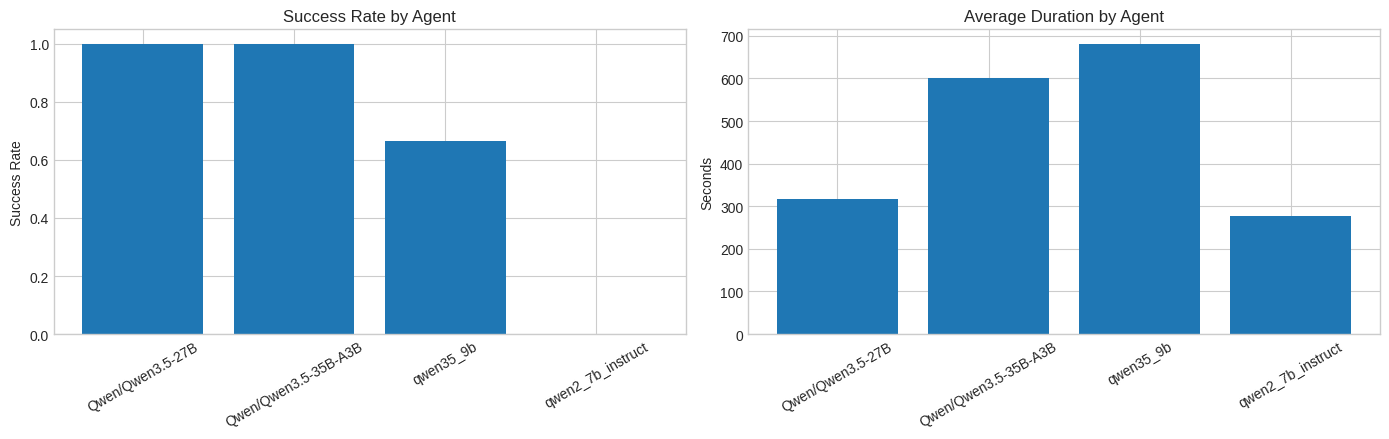

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

agent_plot = agent_perf.reset_index()
axes[0].bar(agent_plot["agent"], agent_plot["success_rate"])
axes[0].set_title("Success Rate by Agent")
axes[0].set_ylabel("Success Rate")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(agent_plot["agent"], agent_plot["avg_duration_sec"])
axes[1].set_title("Average Duration by Agent")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Benchmark-Level View

Compare benchmark tasks on reliability and quality.

In [17]:
benchmark_perf = (
    runs.groupby("benchmark_id", dropna=False)
    .agg(
        runs=("benchmark_id", "size"),
        success_rate=("success", "mean"),
        avg_duration_sec=("duration_sec", "mean"),
        avg_precision=("precision", "mean"),
        avg_recall=("recall", "mean"),
        avg_f1=("f1", "mean"),
        avg_false_positives=("false_positive_count", "mean"),
        avg_missed=("missed_count", "mean"),
    )
    .sort_values("success_rate", ascending=False)
)

benchmark_perf

,runs,success_rate,avg_duration_sec,avg_precision,avg_recall,avg_f1,avg_false_positives,avg_missed
benchmark_id,,,,,,,,
loitering_detection_injected,4,0.75,372.809525,1.000000,0.75,1.000000,0.00,2.5
speeding_detection_injected,4,0.75,141.504300,0.914141,0.75,0.953824,0.75,2.5
disappearance_detection_injected,4,0.50,892.239341,1.000000,0.50,1.000000,0.00,5.0


## Agent x Benchmark Performance Matrix

Visualize how each agent performs on each benchmark using heatmaps for:
- Success rate
- Recall (detected expected / expected)
- Average runtime

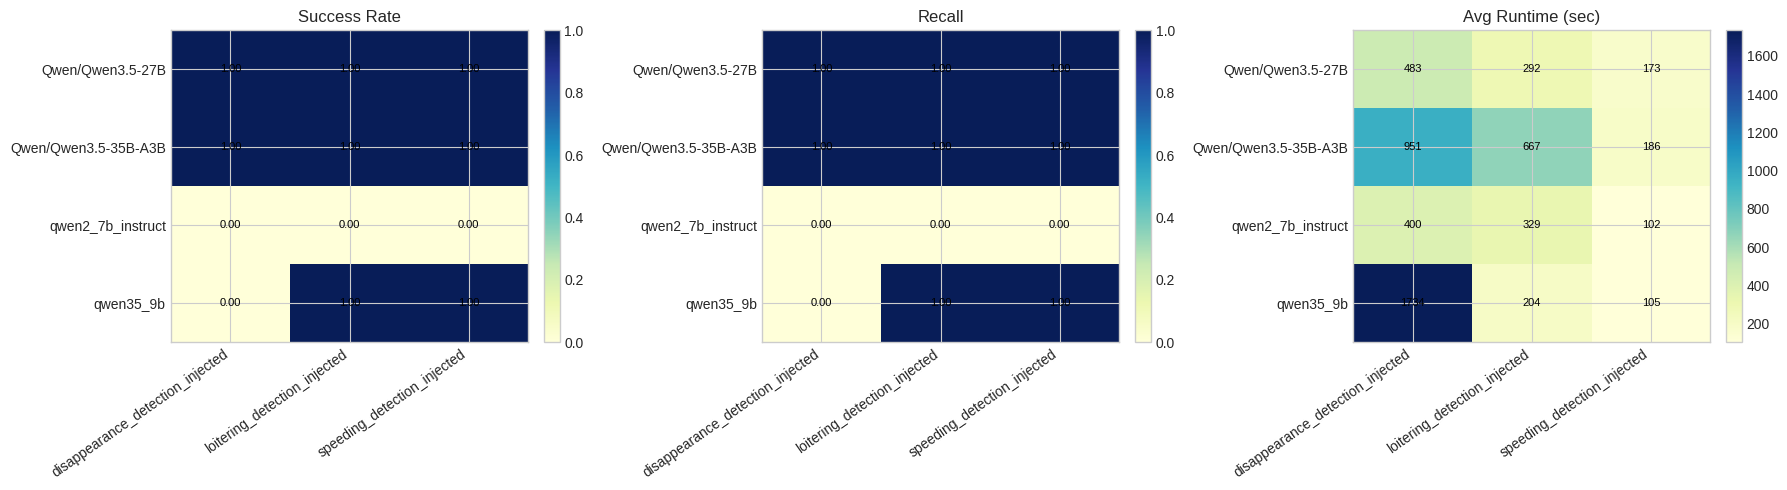

In [18]:
matrix = (
    runs.groupby(["agent", "benchmark_id"], dropna=False)
    .agg(
        success_rate=("success", "mean"),
        avg_recall=("recall", "mean"),
        avg_duration_sec=("duration_sec", "mean"),
    )
    .reset_index()
)

metrics_to_plot = [
    ("success_rate", "Success Rate", 0, 1),
    ("avg_recall", "Recall", 0, 1),
    ("avg_duration_sec", "Avg Runtime (sec)", None, None),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric_col, title, vmin, vmax) in zip(axes, metrics_to_plot):
    pivot = matrix.pivot(index="agent", columns="benchmark_id", values=metric_col)
    values = pivot.values.astype(float)

    im = ax.imshow(values, aspect="auto", vmin=vmin, vmax=vmax, cmap="YlGnBu")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isfinite(val):
                text_val = f"{val:.2f}" if metric_col != "avg_duration_sec" else f"{val:.0f}"
                ax.text(j, i, text_val, ha="center", va="center", color="black", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Run-Level Quality Tradeoff

This chart highlights per-run tradeoffs:
- x-axis: recall
- y-axis: false positives
- marker size: runtime
- marker color: benchmark

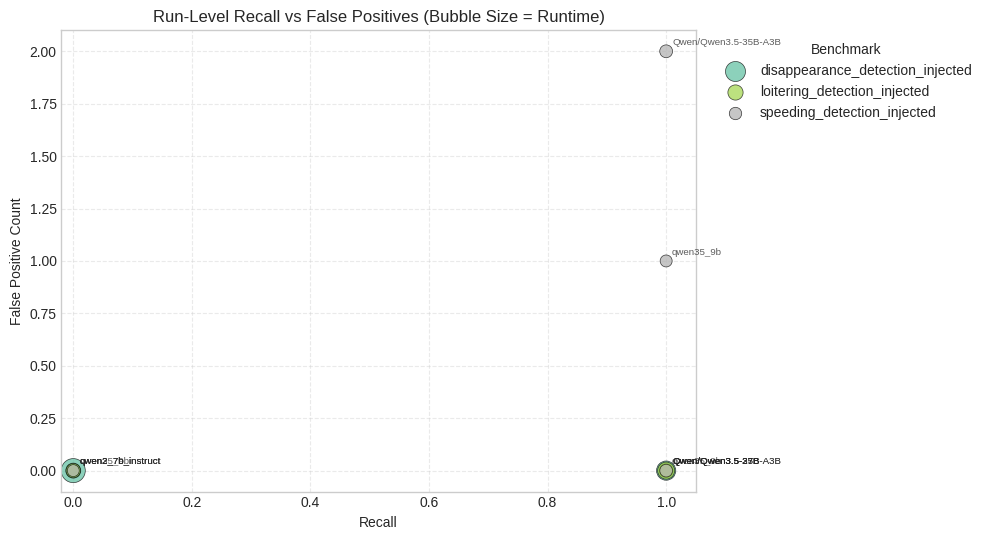

In [19]:
plot_df = runs.copy()
plot_df["duration_for_size"] = plot_df["duration_sec"].fillna(plot_df["duration_sec"].median())

if plot_df["duration_for_size"].max() > 0:
    marker_sizes = 60 + 240 * (plot_df["duration_for_size"] / plot_df["duration_for_size"].max())
else:
    marker_sizes = np.full(len(plot_df), 80)

benchmarks = sorted(plot_df["benchmark_id"].dropna().unique())
colors = plt.cm.Set2(np.linspace(0, 1, max(len(benchmarks), 1)))
color_map = dict(zip(benchmarks, colors))

fig, ax = plt.subplots(figsize=(10, 5.5))

for bench in benchmarks:
    subset = plot_df[plot_df["benchmark_id"] == bench]
    ax.scatter(
        subset["recall"],
        subset["false_positive_count"],
        s=marker_sizes.loc[subset.index],
        alpha=0.75,
        label=bench,
        color=color_map[bench],
        edgecolor="black",
        linewidth=0.5,
    )

for _, row in plot_df.iterrows():
    ax.text(
        row["recall"] + 0.01 if pd.notna(row["recall"]) else 0.01,
        row["false_positive_count"] + 0.03,
        str(row["agent"]),
        fontsize=7,
        alpha=0.75,
    )

ax.set_title("Run-Level Recall vs False Positives (Bubble Size = Runtime)")
ax.set_xlabel("Recall")
ax.set_ylabel("False Positive Count")
ax.set_xlim(-0.02, 1.05)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(title="Benchmark", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Failed Runs and Error Diagnostics

Inspect failed runs to quickly identify systematic issues (tooling, schema assumptions, model formatting).

## Output Format Compliance and Failure Patterns

Classify each run's `agent_output` to separate quality misses from formatting/instruction-following failures.

,agent,output_class,count
0,Qwen/Qwen3.5-27B,valid_json_schema,3
1,Qwen/Qwen3.5-35B-A3B,json_list_instead_of_object,1
2,Qwen/Qwen3.5-35B-A3B,non_json_text,1
3,Qwen/Qwen3.5-35B-A3B,valid_json_schema,1
5,qwen2_7b_instruct,narrative_with_code_fence,2
4,qwen2_7b_instruct,json_list_instead_of_object,1
7,qwen35_9b,valid_json_schema,2
6,qwen35_9b,json_list_instead_of_object,1


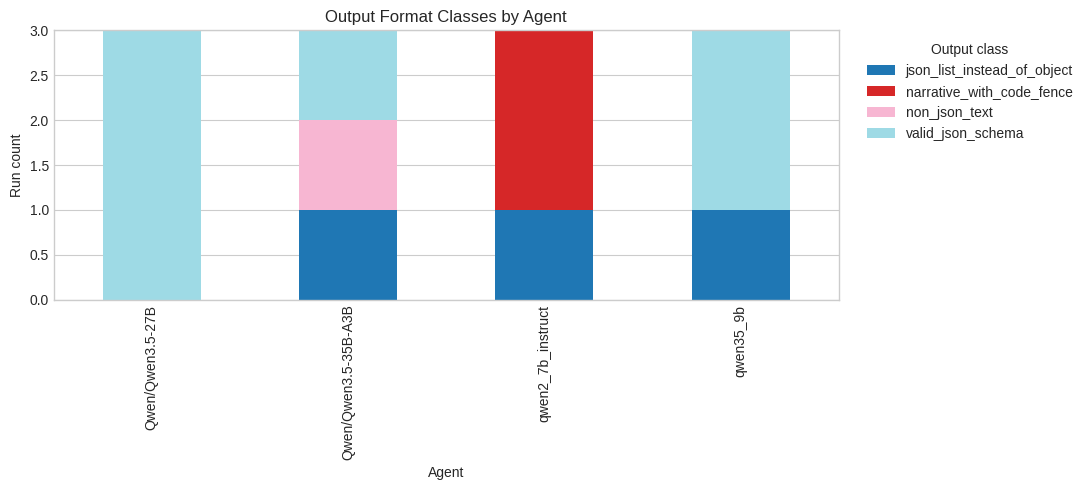

In [20]:
def expected_key_from_benchmark(benchmark_id: str) -> str:
    if not isinstance(benchmark_id, str):
        return "unknown_mmsi"
    prefix = benchmark_id.split("_detection", 1)[0]
    return f"{prefix}_mmsi"


def classify_output(row: pd.Series) -> str:
    text = str(row.get("agent_output", "")).strip()
    expected_key = expected_key_from_benchmark(row.get("benchmark_id"))

    if not text:
        return "empty_output"

    try:
        parsed = json.loads(text)

        if isinstance(parsed, list):
            return "json_list_instead_of_object"

        if isinstance(parsed, dict):
            if expected_key not in parsed:
                return "json_missing_expected_key"
            if not isinstance(parsed[expected_key], list):
                return "json_key_not_list"
            if len(parsed[expected_key]) == 0:
                return "valid_schema_empty_list"
            return "valid_json_schema"

        return "json_non_object"
    except Exception:
        lower = text.lower()
        if "```" in text:
            return "narrative_with_code_fence"
        if any(token in lower for token in ["unable", "issue", "error", "constraints", "cannot"]):
            return "narrative_error_explanation"
        return "non_json_text"


runs["output_class"] = runs.apply(classify_output, axis=1)

output_class_counts = (
    runs.groupby(["agent", "output_class"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
)

display(output_class_counts.sort_values(["agent", "count"], ascending=[True, False]))

plot_table = output_class_counts.pivot(index="agent", columns="output_class", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
plot_table.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Output Format Classes by Agent")
ax.set_xlabel("Agent")
ax.set_ylabel("Run count")
ax.legend(title="Output class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

,agent,benchmark_id,false_positive_events,missed_events
1,qwen2_7b_instruct,disappearance_detection_injected,0.0,10.0
4,qwen35_9b,disappearance_detection_injected,0.0,10.0
2,qwen2_7b_instruct,loitering_detection_injected,0.0,10.0
0,Qwen/Qwen3.5-35B-A3B,speeding_detection_injected,2.0,0.0
3,qwen2_7b_instruct,speeding_detection_injected,0.0,10.0
5,qwen35_9b,speeding_detection_injected,1.0,0.0


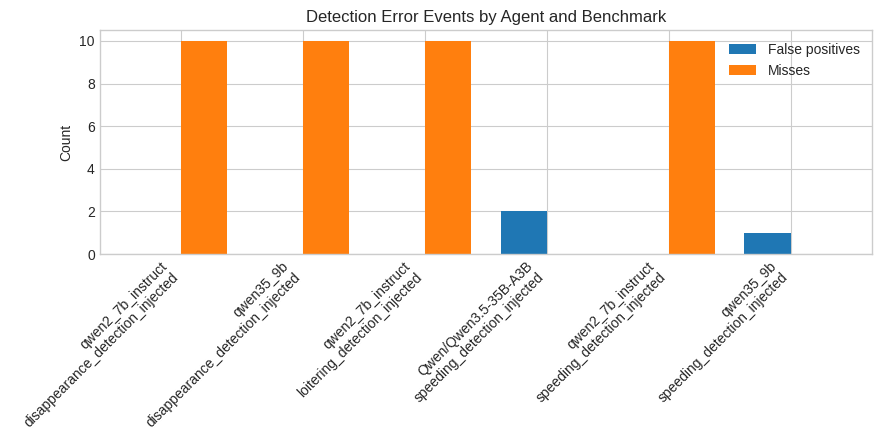

In [21]:
# MMSI-level false positives and misses by agent
fp_long = runs[["agent", "benchmark_id", "false_positive_mmsis"]].explode("false_positive_mmsis").dropna(subset=["false_positive_mmsis"])
miss_long = runs[["agent", "benchmark_id", "missed_expected_mmsis"]].explode("missed_expected_mmsis").dropna(subset=["missed_expected_mmsis"])

fp_counts = fp_long.groupby(["agent", "benchmark_id"]).size().rename("false_positive_events").reset_index()
miss_counts = miss_long.groupby(["agent", "benchmark_id"]).size().rename("missed_events").reset_index()

quality_events = (
    fp_counts.merge(miss_counts, on=["agent", "benchmark_id"], how="outer")
    .fillna(0)
    .sort_values(["benchmark_id", "agent"])
)

if quality_events.empty:
    print("No false-positive or missed-event details found.")
else:
    display(quality_events)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    width = 0.38
    x = np.arange(len(quality_events))

    ax.bar(x - width / 2, quality_events["false_positive_events"], width=width, label="False positives")
    ax.bar(x + width / 2, quality_events["missed_events"], width=width, label="Misses")

    labels = [f"{a}\n{b}" for a, b in zip(quality_events["agent"], quality_events["benchmark_id"])]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Count")
    ax.set_title("Detection Error Events by Agent and Benchmark")
    ax.legend()
    plt.tight_layout()
    plt.show()

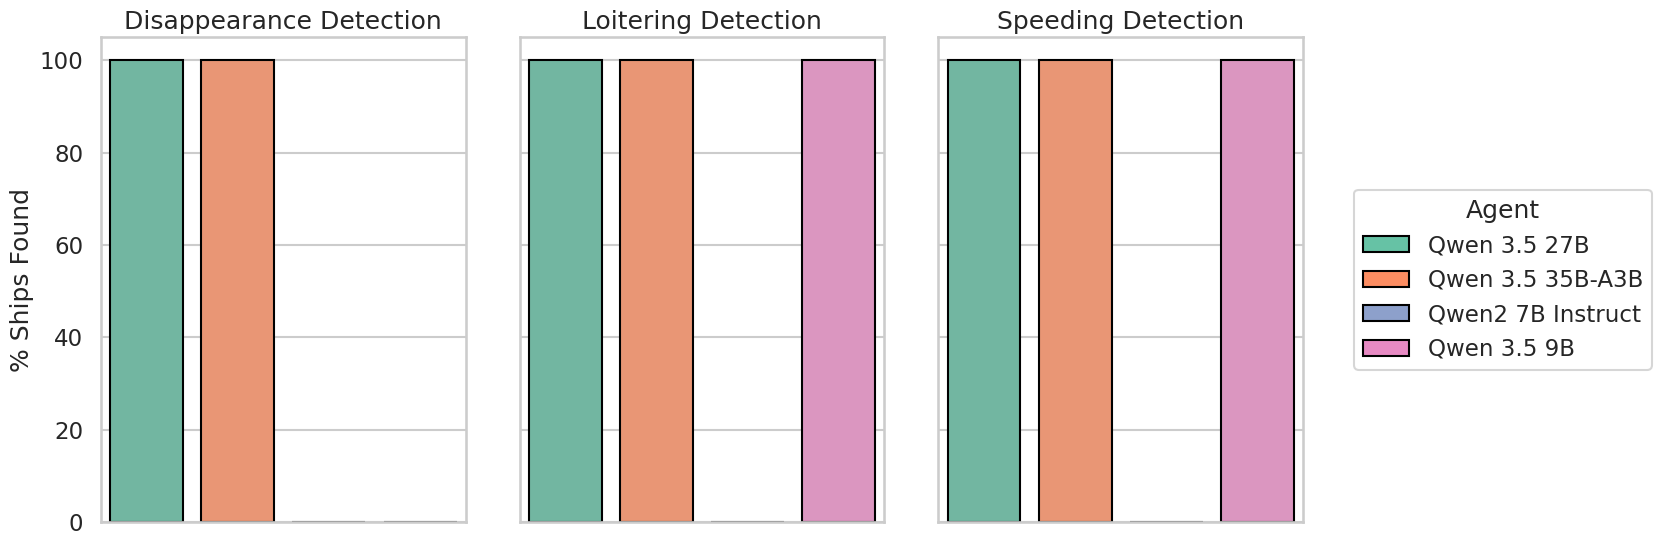

In [33]:
import seaborn as sns
from matplotlib.patches import Patch

# Three benchmark-specific plots: % ships found by agent with one shared legend
perf_by_benchmark_agent = (
    runs.groupby(["benchmark_id", "agent"], dropna=False)["recall"]
    .mean()
    .mul(100)
    .reset_index(name="pct_ships_found")
)

friendly_benchmark_names = {
    "loitering_detection_injected": "Loitering Detection",
    "speeding_detection_injected": "Speeding Detection",
    "disappearance_detection_injected": "Disappearance Detection",
}

# Short labels for compact legend display
friendly_agent_names = {
    "Qwen/Qwen3.5-27B": "Qwen 3.5 27B",
    "Qwen/Qwen3.5-35B-A3B": "Qwen 3.5 35B-A3B",
    "qwen2_7b_instruct": "Qwen2 7B Instruct",
    "qwen35_9b": "Qwen 3.5 9B",
}

perf_by_benchmark_agent["benchmark_label"] = perf_by_benchmark_agent["benchmark_id"].map(
    lambda x: friendly_benchmark_names.get(x, str(x).replace("_", " ").title())
)
perf_by_benchmark_agent["agent_label"] = perf_by_benchmark_agent["agent"].map(
    lambda x: friendly_agent_names.get(x, str(x))
)

if perf_by_benchmark_agent.empty:
    print("No data available for benchmark-agent performance plots.")
else:
    benchmark_order = [
        friendly_benchmark_names.get(b, str(b).replace("_", " ").title())
        for b in sorted(perf_by_benchmark_agent["benchmark_id"].dropna().unique())
    ]
    agent_order = [
        friendly_agent_names.get(a, str(a))
        for a in sorted(perf_by_benchmark_agent["agent"].dropna().unique())
    ]

    sns.set_theme(style="whitegrid", context="talk")
    palette_colors = sns.color_palette("Set2", n_colors=len(agent_order))
    palette_map = dict(zip(agent_order, palette_colors))

    # Use a dedicated legend column to avoid awkward empty whitespace.
    fig, axes = plt.subplots(
        1,
        len(benchmark_order) + 1,
        figsize=(4.8 * len(benchmark_order) + 2.8, 5.8),
        sharey=True,
        gridspec_kw={"width_ratios": [1] * len(benchmark_order) + [0.8]},
    )

    chart_axes = axes[:-1]
    legend_ax = axes[-1]

    for ax, benchmark_label in zip(chart_axes, benchmark_order):
        subset = perf_by_benchmark_agent[perf_by_benchmark_agent["benchmark_label"] == benchmark_label]
        sns.barplot(
            data=subset,
            x="agent_label",
            y="pct_ships_found",
            hue="agent_label",
            order=agent_order,
            hue_order=agent_order,
            dodge=False,
            palette=palette_map,
            edgecolor="black",
            legend=False,
            ax=ax,
        )
        ax.set_title(benchmark_label)
        ax.set_xlabel("")
        ax.set_ylabel("% Ships Found")
        ax.set_ylim(0, 105)
        ax.tick_params(axis="x", labelbottom=False)

    legend_handles = [Patch(facecolor=palette_map[label], edgecolor="black", label=label) for label in agent_order]
    legend_ax.axis("off")
    legend_ax.legend(
        handles=legend_handles,
        labels=agent_order,
        title="Agent",
        loc="center",
        frameon=True,
        ncol=1,
    )

    plt.tight_layout()
    plt.show()